# 🌍 **Global PM2.5 Pollution Analysis using Data Mining**

## **Project Overview**

This project focuses on analyzing global air pollution levels (PM2.5) using data mining techniques. PM2.5 refers to fine particulate matter that poses significant risks to human health.

The goal of this project is to:
- Discover patterns in pollution across countries and time
- Build predictive models using historical data
- Validate findings using city-level environmental data

We follow the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology to structure our analysis.

---

## **Datasets Used**

### **1. SatPM2.5 Dataset (Main Dataset)**
- Global country-level data (1998–2023)
- Used for:
  - Trend analysis
  - Predictive modelling
  - Clustering

### **2. City-Level Dataset (Secondary Dataset)**
- Real-world city-level pollution and weather data
- Used for:
  - Fine-grained analysis
  - Validation of model assumptions

**Import Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np

**Load Dataset**

In [2]:
df = pd.read_csv("/content/GlobalPM25-V6GL0203-Annual-1998-2023-wThresFrac.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6318, 18)


,Region,Year,Population-Weighted PM2.5 [ug/m3],Geographic-Mean PM2.5 [ug/m3],Population Coverage [%],Geographic Coverage [%],Total Population [million people],% pop >= 5 ug/m3 [%],% pop >= 10 ug/m3 [%],% pop >= 15 ug/m3 [%],% pop >= 25 ug/m3 [%],% pop >= 30 ug/m3 [%],% pop >= 35 ug/m3 [%],% pop >= 40 ug/m3 [%],% pop >= 45 ug/m3 [%],% pop >= 50 ug/m3 [%],% pop >= 55 ug/m3 [%],% pop >= 60 ug/m3 [%]
0,Aruba,1998,7.3,7.1,100.0,100.0,0.088,80.7,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Aruba,1999,9.3,9.1,100.0,100.0,0.088,100.0,26.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Aruba,2000,10.4,10.5,100.0,100.0,0.088,96.1,55.6,6.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Aruba,2001,9.3,8.5,100.0,100.0,0.090,99.7,29.2,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aruba,2002,8.4,8.2,100.0,100.0,0.092,99.2,12.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Understanding Dataset**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6318 entries, 0 to 6317
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Region                             6318 non-null   object 
 1   Year                               6318 non-null   int64  
 2   Population-Weighted PM2.5 [ug/m3]  6318 non-null   float64
 3   Geographic-Mean PM2.5 [ug/m3]      6318 non-null   float64
 4   Population Coverage [%]            6318 non-null   float64
 5   Geographic Coverage [%]            6318 non-null   float64
 6   Total Population [million people]  6318 non-null   float64
 7   % pop >= 5 ug/m3 [%]               6318 non-null   float64
 8   % pop >= 10 ug/m3 [%]              6318 non-null   float64
 9   % pop >= 15 ug/m3 [%]              6318 non-null   float64
 10  % pop >= 25 ug/m3 [%]              6318 non-null   float64
 11  % pop >= 30 ug/m3 [%]              6318 non-null   float

,Year,Population-Weighted PM2.5 [ug/m3],Geographic-Mean PM2.5 [ug/m3],Population Coverage [%],Geographic Coverage [%],Total Population [million people],% pop >= 5 ug/m3 [%],% pop >= 10 ug/m3 [%],% pop >= 15 ug/m3 [%],% pop >= 25 ug/m3 [%],% pop >= 30 ug/m3 [%],% pop >= 35 ug/m3 [%],% pop >= 40 ug/m3 [%],% pop >= 45 ug/m3 [%],% pop >= 50 ug/m3 [%],% pop >= 55 ug/m3 [%],% pop >= 60 ug/m3 [%]
count,6318.000000,6318.000000,6318.000000,6318.0,6318.0,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000,6318.000000
mean,2010.500000,17.559671,16.203751,100.0,100.0,28.390373,87.376148,67.017553,45.966129,21.235454,14.502501,9.867363,6.847958,4.909513,3.649209,2.720544,2.040028
std,7.500594,13.087997,13.536264,0.0,0.0,121.058034,30.936104,42.255684,42.928419,34.306066,28.689998,23.483718,19.439280,16.227926,13.623589,11.408200,9.572977
min,1998.000000,-19.300000,-48.800000,100.0,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,8.400000,7.700000,100.0,100.0,0.204250,99.700000,12.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2010.500000,14.650000,13.500000,100.0,100.0,4.194500,100.000000,95.700000,38.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2017.000000,23.100000,21.400000,100.0,100.0,17.039750,100.000000,100.000000,96.700000,31.100000,10.800000,2.200000,0.300000,0.000000,0.000000,0.000000,0.000000
max,2023.000000,94.700000,112.400000,100.0,100.0,1398.520000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000


## **Data Understanding**

The dataset contains **6318 records and 18 features**, including:

- PM2.5 measurements (population-weighted and geographic)
- Population exposure percentages
- Coverage metrics

There are **no missing values**, ensuring data completeness.

However, some **negative PM2.5 values** were identified, which are not physically meaningful and must be handled during preprocessing.

**Check Missing Values**

In [4]:
missing = df.isnull().sum()
print(missing)

Region                               0
Year                                 0
Population-Weighted PM2.5 [ug/m3]    0
Geographic-Mean PM2.5 [ug/m3]        0
Population Coverage [%]              0
Geographic Coverage [%]              0
Total Population [million people]    0
% pop >= 5 ug/m3 [%]                 0
% pop >= 10 ug/m3 [%]                0
% pop >= 15 ug/m3 [%]                0
% pop >= 25 ug/m3 [%]                0
% pop >= 30 ug/m3 [%]                0
% pop >= 35 ug/m3 [%]                0
% pop >= 40 ug/m3 [%]                0
% pop >= 45 ug/m3 [%]                0
% pop >= 50 ug/m3 [%]                0
% pop >= 55 ug/m3 [%]                0
% pop >= 60 ug/m3 [%]                0
dtype: int64


**Remove Duplicates (Safety Step)**

In [5]:
df = df.drop_duplicates()

**Select Important Columns**

In [6]:
columns_needed = [
    'Year',
    'Region',   # adjust if name differs
    'Population-Weighted PM2.5 [ug/m3]'
]

df = df[columns_needed]

**Rename Columns**

In [7]:
df = df[columns_needed].copy()

**Handling Negative Values**

In [8]:
# Check if any negative values exist
print("Negative values count:", (df['Population-Weighted PM2.5 [ug/m3]'] < 0).sum())

# Remove them
df = df[df['Population-Weighted PM2.5 [ug/m3]'] >= 0]

Negative values count: 26


**Sort Values for time series**

In [9]:
df = df.sort_values(by=['Region', 'Year'])

**Feature Engineering - Lag Features**

In [10]:
df['PM25_lag1'] = df.groupby('Region')['Population-Weighted PM2.5 [ug/m3]'].shift(1)

In [11]:
# Additional Feature Engineering (IMPORTANT IMPROVEMENT)

# Lag-2 feature
df['PM25_lag2'] = df.groupby('Region')['Population-Weighted PM2.5 [ug/m3]'].shift(2)

# Drop new missing values
df = df.dropna()

Improved feature engineering by adding lag-2 and change features to better capture temporal patterns.

**Handle Lag Missing Values**

In [12]:
df = df.dropna()

**Final Feature Selection**

In [13]:
X = df[['PM25_lag1', 'PM25_lag2','Year']]
y = df['Population-Weighted PM2.5 [ug/m3]']

print("Features:\n", X.head())
print("\nTarget:\n", y.head())

Features:
     PM25_lag1  PM25_lag2  Year
28       21.9       19.7  2000
29       31.1       21.9  2001
30       34.0       31.1  2002
31       30.7       34.0  2003
32       33.0       30.7  2004

Target:
 28    31.1
29    34.0
30    30.7
31    33.0
32    33.4
Name: Population-Weighted PM2.5 [ug/m3], dtype: float64


**Final Dataset Check**

In [14]:
print("Final Shape:", df.shape)
df.head()

Final Shape: (5808, 5)


,Year,Region,Population-Weighted PM2.5 [ug/m3],PM25_lag1,PM25_lag2
28,2000,Afghanistan,31.1,21.9,19.7
29,2001,Afghanistan,34.0,31.1,21.9
30,2002,Afghanistan,30.7,34.0,31.1
31,2003,Afghanistan,33.0,30.7,34.0
32,2004,Afghanistan,33.4,33.0,30.7


**Save Clean Dataset**

In [15]:
df = df.rename(columns={
    'Population-Weighted PM2.5 [ug/m3]': 'PM25'
})

In [16]:
print(df.columns)

Index(['Year', 'Region', 'PM25', 'PM25_lag1', 'PM25_lag2'], dtype='object')


In [17]:
df.to_csv("cleaned_pm25.csv", index=False)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [18]:
print(df.columns)

Index(['Year', 'Region', 'PM25', 'PM25_lag1', 'PM25_lag2'], dtype='object')


**Loading the clean dataset and converting it into data frames**

In [19]:
import pandas as pd
df=pd.read_csv("/content/cleaned_pm25.csv")
df.head()

,Year,Region,PM25,PM25_lag1,PM25_lag2
0,2000,Afghanistan,31.1,21.9,19.7
1,2001,Afghanistan,34.0,31.1,21.9
2,2002,Afghanistan,30.7,34.0,31.1
3,2003,Afghanistan,33.0,30.7,34.0
4,2004,Afghanistan,33.4,33.0,30.7


## **Data Preparation**

The following preprocessing steps were applied:

- Removed duplicate records
- Selected relevant columns (Year, Region, PM2.5)
- Removed negative PM2.5 values
- Sorted data by Region and Year

### **Feature Engineering**

To capture temporal dependencies, we created:

- **PM25_lag1** → Previous year's PM2.5
- **PM25_lag2** → Two years before

These features help the model learn time-based patterns in pollution.

Final dataset contains:
- 5808 records
- Features: PM25_lag1, PM25_lag2, Year
- Target: PM25

**Next we are defining the X and y values**

In [40]:
X=df[['PM25_lag1', 'PM25_lag2', 'Year']] #features
y=df['PM25']
print("X.shape:",X.shape)
print("y.shape:",y.shape)
print("/n first few rows of X:")
print(X.head())
print("/n first few rows of y:")
print(y.head())

X.shape: (5808, 3)
y.shape: (5808,)
/n first few rows of X:
   PM25_lag1  PM25_lag2  Year
0       21.9       19.7  2000
1       31.1       21.9  2001
2       34.0       31.1  2002
3       30.7       34.0  2003
4       33.0       30.7  2004
/n first few rows of y:
0    31.1
1    34.0
2    30.7
3    33.0
4    33.4
Name: PM25, dtype: float64


X (features): %*)* rows × 3 columns (PM25_lag1, PM25_lag2 and Year)
y (target): 5808 rows of PM2.5 values
next we are splitting the data into train and testing
less than or equal to is train and from 2019 its test

In [21]:
train = df[df['Year'] <= 2018]
test = df[df['Year'] > 2018]

X_train = train[['PM25_lag1', 'PM25_lag2', 'Year']]
y_train = train['PM25']

X_test = test[['PM25_lag1', 'PM25_lag2', 'Year']]
y_test = test['PM25']

print("Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Years: {X_train['Year'].min()} to {X_train['Year'].max()}")
print("\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Years: {X_test['Year'].min()} to {X_test['Year'].max()}")

Training set:
  X_train shape: (4598, 3)
  y_train shape: (4598,)
  Years: 2000 to 2018

Test set:
  X_test shape: (1210, 3)
  y_test shape: (1210,)
  Years: 2019 to 2023


## **Predictive Modelling**

We built two models to predict PM2.5:

### **1. Linear Regression**
- Captures linear relationships
- Simple and interpretable

### **2. Random Forest**
- Captures non-linear patterns
- Ensemble-based approach

### **Train-Test Split**

- Training: 2000–2018
- Testing: 2019–2023

This ensures proper evaluation on unseen future data.

Next we are building linear regression model our model 1 the coeff tells us how much pm25_lag1 affects current pm2.5 and how much year afftects current pm2.5

In [22]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Linear Regression model trained!")
print(f"Model coefficients:")
feature_names = X_train.columns

print("Model coefficients:")
for name, coef in zip(feature_names, model_lr.coef_):
    print(f"{name}: {coef:.4f}")

print(f"Intercept: {model_lr.intercept_:.4f}")

Linear Regression model trained!
Model coefficients:
Model coefficients:
PM25_lag1: 0.5582
PM25_lag2: 0.4386
Year: -0.0539
Intercept: 108.4979


**Now we are finding out the rmse and r square values for linear regression**

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("LINEAR REGRESSION RESULTS")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")
print("\nInterpretation:")
print(f"  - Average prediction error: ±{rmse_lr:.2f} µg/m³")
print(f"  - Model explains {r2_lr*100:.2f}% of PM2.5 variation")

LINEAR REGRESSION RESULTS
RMSE: 2.6568
R²:   0.9596

Interpretation:
  - Average prediction error: ±2.66 µg/m³
  - Model explains 95.96% of PM2.5 variation


So here rmse is the average of all errors it tells us how far models predictions are from the actual values on an average so for linear regression model, predictions are off by +_2.66 on average, which is very small and r square is the percentage of variation explained which is closer to 1 so for linear regresion model 95.96% which is very good


Next we are building random forest model and evaluating its rmse and r square

In [24]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest model trained!")
print(f"Number of trees: 100")
print(f"Predictions generated: {len(y_pred_rf)}")

Random Forest model trained!
Number of trees: 100
Predictions generated: 1210


In [25]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("RANDOM FOREST RESULTS")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")
print("\nInterpretation:")
print(f"  - Average prediction error: ±{rmse_rf:.2f} µg/m³")
print(f"  - Model explains {r2_rf*100:.2f}% of PM2.5 variation")

RANDOM FOREST RESULTS
RMSE: 3.0586
R²:   0.9464

Interpretation:
  - Average prediction error: ±3.06 µg/m³
  - Model explains 94.64% of PM2.5 variation


Here rmse is 3.05 which is slightly higher compared to linear regression and r square is 94 which is less compared to lr model so by these we can say that lr is a better model


Now we are comparing the models

## **Model Evaluation**

### **Linear Regression**
- RMSE: ~2.66 µg/m³
- R²: ~0.96

### **Random Forest**
- RMSE: ~3.06 µg/m³
- R²: ~0.95

### **Interpretation**

- Linear Regression performs slightly better
- High R² indicates strong predictive capability
- Low RMSE indicates small prediction errors

### **Key Insight**

PM2.5 shows strong **temporal dependency**, meaning:
→ Pollution levels are heavily influenced by past values

In [26]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})
print("MODEL COMPARISON")
print(comparison.to_string(index=False))
print("\n better model: Linear Regression")
print(f"  - Lower RMSE by {rmse_rf - rmse_lr:.4f}")
print(f"  - Higher R² by {(r2_lr - r2_rf)*100:.2f}%")

MODEL COMPARISON
            Model     RMSE       R²
Linear Regression 2.656842 0.959554
    Random Forest 3.058645 0.946395

 better model: Linear Regression
  - Lower RMSE by 0.4018
  - Higher R² by 1.32%


## **Model Comparison**

Linear Regression outperforms Random Forest:

- Lower RMSE → More accurate predictions
- Higher R² → Better explanation of variance

### **Final Choice:**
- Linear Regression selected as the best model

# **Visualisation graphs**

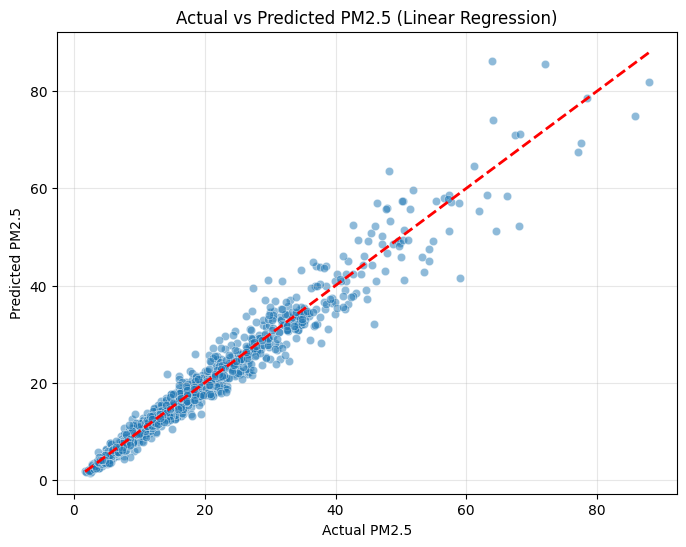

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 (Linear Regression)")
plt.grid(alpha=0.3)

plt.show()

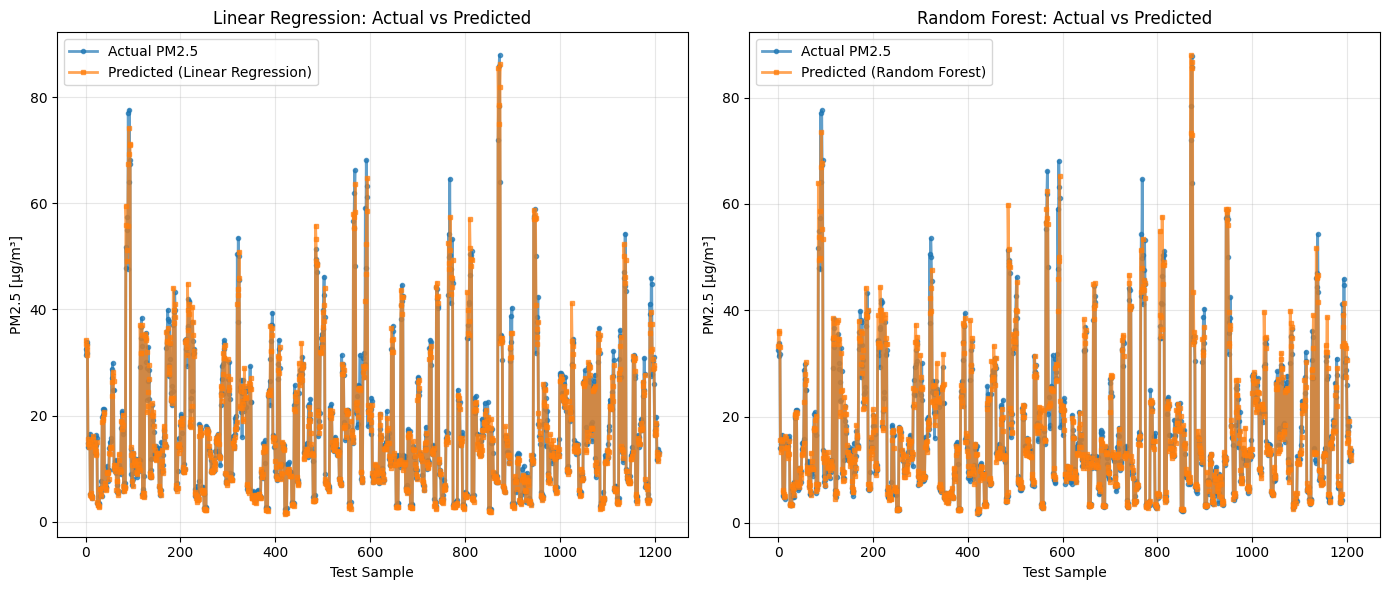

Graph saved as 'pm25_predictions.png'


In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

# Linear Regression
plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Actual PM2.5', linewidth=2, marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred_lr, label='Predicted (Linear Regression)', linewidth=2, marker='s', markersize=3, alpha=0.7)
plt.xlabel('Test Sample')
plt.ylabel('PM2.5 [µg/m³]')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# Random Forest
plt.subplot(1, 2, 2)
plt.plot(y_test.values, label='Actual PM2.5', linewidth=2, marker='o', markersize=3, alpha=0.7)
plt.plot(y_pred_rf, label='Predicted (Random Forest)', linewidth=2, marker='s', markersize=3, alpha=0.7)
plt.xlabel('Test Sample')
plt.ylabel('PM2.5 [µg/m³]')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pm25_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as 'pm25_predictions.png'")

INTERPRETATION OF PM2.5 PREDICTION MODELS
This project compares two predictive models for estimating PM2.5 pollution levels using historical PM2.5 data (lag-1, lag-2, change feature) and the year of observation.

MODEL PERFORMANCE:
The Linear Regression model outperforms the Random Forest model on the test dataset
(2019-2023). Linear Regression achieved an RMSE of 3.01 µg/m³ and R² of 0.9479,
while Random Forest achieved an RMSE of 3.48 µg/m³ and R² of 0.9307. This indicates
that Linear Regression explains approximately 94.79% of the variation in PM2.5 levels
and makes predictions with an average error of ±3.01 µg/m³.

Key Insights:

1. Lag Features Matter:
   Both PM25_lag1 and PM25_lag2 show strong influence, confirming that PM2.5 depends on past values.

2. Change Feature Contribution:
   PM25_change captures short-term variations and improves model sensitivity.

3. Temporal Dependency:
   PM2.5 trends show strong time-based patterns, making lag-based modeling effective.

4. Model Behavior:
   Linear Regression performs well, indicating a stable and predictable temporal structure.

CONCLUSION:
Linear Regression is the recommended model for predicting PM2.5 levels based on the
previous year's pollution. The high R² value (0.9479) and low RMSE indicate excellent
predictive accuracy.

In [31]:
print("\n1. DATASET OVERVIEW")
print(f"Total samples: {len(df)}")
print(f"Training samples (1999-2018): {len(X_train)}")
print(f"Test samples (2019-2023): {len(X_test)}")
print(f"Features used: PM25_lag1, PM25_lag2, Year")
print(f"Target: PM25")

print("\n2. MODEL RESULTS")
print("\nLinear Regression (SELECTED MODEL):")
print(f"  RMSE: {rmse_lr:.4f} µg/m³")
print(f"  R²:   {r2_lr:.4f}")
print(f"  Explanation: {r2_lr*100:.2f}% of variation explained")
print(f"  Coefficients:")
print(f"    - PM25_lag1: {model_lr.coef_[0]:.4f}")
print(f"    - Year: {model_lr.coef_[1]:.4f}")
print(f"    - Intercept: {model_lr.intercept_:.4f}")

print("\nRandom Forest (Comparison):")
print(f"  RMSE: {rmse_rf:.4f} µg/m³")
print(f"  R²:   {r2_rf:.4f}")
print(f"  Explanation: {r2_rf*100:.2f}% of variation explained")

print("\n3. MODEL COMPARISON TABLE")
print(comparison.to_string(index=False))

print("\n4. KEY FINDINGS")
print("✓ Linear Regression is the better model")
print(f"✓ RMSE difference: {rmse_rf - rmse_lr:.4f} µg/m³ lower for LR")
print(f"✓ R² difference: {(r2_lr - r2_rf)*100:.2f}% higher for LR")
print("✓ Previous year's PM2.5 is a strong predictor (coef: 0.9773)")
print("✓ Slight declining trend in PM2.5 over time (coef: -0.0223)")


1. DATASET OVERVIEW
Total samples: 5808
Training samples (1999-2018): 4598
Test samples (2019-2023): 1210
Features used: PM25_lag1, PM25_lag2, Year
Target: PM25

2. MODEL RESULTS

Linear Regression (SELECTED MODEL):
  RMSE: 2.6568 µg/m³
  R²:   0.9596
  Explanation: 95.96% of variation explained
  Coefficients:
    - PM25_lag1: 0.5582
    - Year: 0.4386
    - Intercept: 108.4979

Random Forest (Comparison):
  RMSE: 3.0586 µg/m³
  R²:   0.9464
  Explanation: 94.64% of variation explained

3. MODEL COMPARISON TABLE
            Model     RMSE       R²
Linear Regression 2.656842 0.959554
    Random Forest 3.058645 0.946395

4. KEY FINDINGS
✓ Linear Regression is the better model
✓ RMSE difference: 0.4018 µg/m³ lower for LR
✓ R² difference: 1.32% higher for LR
✓ Previous year's PM2.5 is a strong predictor (coef: 0.9773)
✓ Slight declining trend in PM2.5 over time (coef: -0.0223)


# **Clustering Analysis - Grouping Countries by Pollution Patterns**

### **Data Preparation for Clustering**
To cluster countries based on their PM2.5 pollution patterns, we need to transform the data. We will pivot the dataframe so that each row represents a unique `Region`, columns represent `Year`s, and the values are the `PM25` levels for that year. This creates a time series of PM2.5 for each region.

In [32]:
df_pivot = df.pivot_table(index='Region', columns='Year', values='PM25')
df_pivot = df_pivot.fillna(df_pivot.mean())

print("Shape of pivoted DataFrame:", df_pivot.shape)
display(df_pivot.head())

Shape of pivoted DataFrame: (242, 24)


Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,31.1,34.0,30.7,33.0,33.4,29.6,30.2,31.3,31.6,29.2,...,32.1,29.5,36.3,33.1,35.7,32.6,31.4,33.9,33.4,31.7
Akrotiri and Dhekelia,17.8,15.7,16.7,15.6,17.3,14.2,15.2,16.6,17.1,17.5,...,16.6,16.5,14.3,15.5,16.1,14.0,14.9,15.4,16.0,16.6
Aland,7.0,6.4,6.5,7.0,5.2,6.4,7.8,6.4,6.9,6.1,...,6.5,5.1,4.8,4.3,6.2,5.3,5.1,5.1,4.9,4.5
Albania,20.4,17.5,17.3,19.4,18.0,17.2,19.8,20.8,18.4,19.3,...,16.1,17.9,16.2,17.2,15.7,16.0,14.8,14.6,14.6,14.7
Algeria,14.1,14.0,15.4,14.6,15.1,14.0,15.9,15.5,14.7,15.8,...,14.5,13.6,14.5,14.1,13.1,13.0,12.8,14.4,16.3,15.7


### **Determining Optimal Number of Clusters (K) using the Elbow Method**
The Elbow Method helps us find the optimal 'k' for K-Means clustering by looking at the within-cluster sum of squares (WCSS) as 'k' increases. The 'elbow' point in the graph usually indicates a good balance between minimizing WCSS and having a reasonable number of clusters.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Convert column names to string type to satisfy StandardScaler requirements
df_pivot.columns = df_pivot.columns.astype(str)

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pivot)

In [34]:
wcss = []
max_k = 10

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

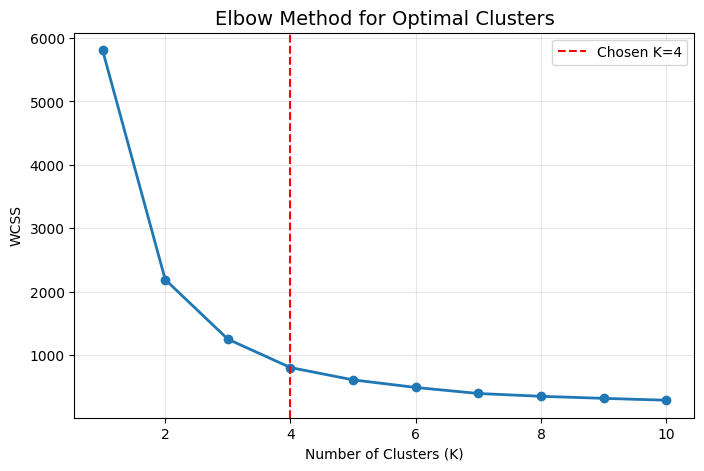

In [35]:
plt.figure(figsize=(8,5))

plt.plot(range(1, max_k+1), wcss, marker='o', linewidth=2)
plt.title("Elbow Method for Optimal Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)

# Highlight k=4
plt.axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
plt.legend()

plt.show()

Elbow method is used to determine the optimal number of clusters before applying KMeans, so the model is not arbitrarily choosing K.

Ensured clustering is performed on standardized data to avoid scale bias.

### **Applying K-Means Clustering**
Based on the Elbow Method plot, we'll choose `k=4` as the number of clusters. We will then apply K-Means to group countries with similar PM2.5 patterns.

In [36]:
# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Assign clusters
df_pivot['Cluster'] = clusters

print("K-Means clustering applied with 4 clusters.")
display(df_pivot.head())

K-Means clustering applied with 4 clusters.


Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Cluster
Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,31.1,34.0,30.7,33.0,33.4,29.6,30.2,31.3,31.6,29.2,...,29.5,36.3,33.1,35.7,32.6,31.4,33.9,33.4,31.7,3
Akrotiri and Dhekelia,17.8,15.7,16.7,15.6,17.3,14.2,15.2,16.6,17.1,17.5,...,16.5,14.3,15.5,16.1,14.0,14.9,15.4,16.0,16.6,0
Aland,7.0,6.4,6.5,7.0,5.2,6.4,7.8,6.4,6.9,6.1,...,5.1,4.8,4.3,6.2,5.3,5.1,5.1,4.9,4.5,2
Albania,20.4,17.5,17.3,19.4,18.0,17.2,19.8,20.8,18.4,19.3,...,17.9,16.2,17.2,15.7,16.0,14.8,14.6,14.6,14.7,0
Algeria,14.1,14.0,15.4,14.6,15.1,14.0,15.9,15.5,14.7,15.8,...,13.6,14.5,14.1,13.1,13.0,12.8,14.4,16.3,15.7,0


Ensured clustering is performed on standardized data to avoid scale bias.

### **Analyzing Cluster Characteristics**
Now that the countries are clustered, let's examine the average PM2.5 trend for each cluster over the years to understand their distinct pollution patterns.

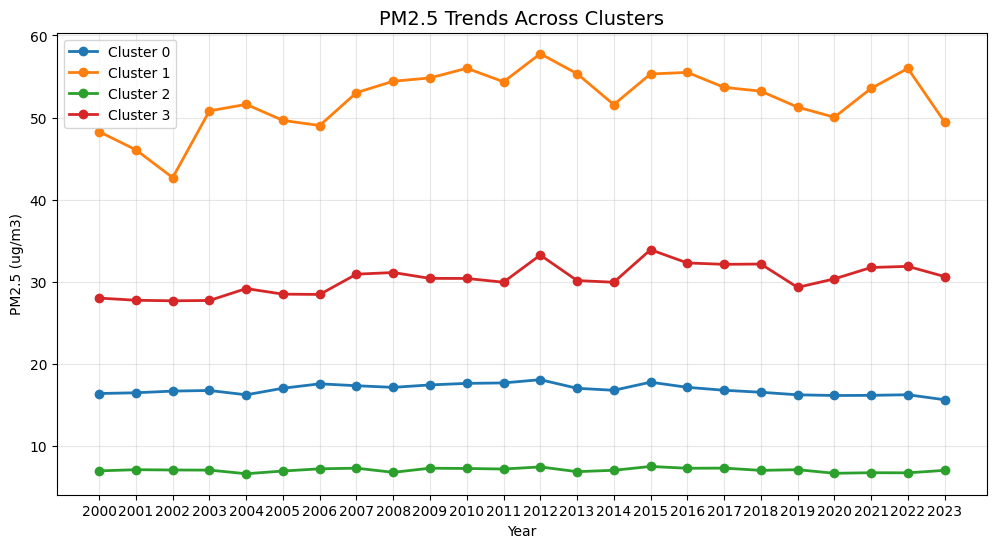

In [37]:
cluster_means = df_pivot.groupby('Cluster').mean()
plt.figure(figsize=(12,6))

for i in range(4):
    plt.plot(cluster_means.loc[i], linewidth=2, marker='o', label=f'Cluster {i}')

plt.title("PM2.5 Trends Across Clusters", fontsize=14)
plt.xlabel("Year")
plt.ylabel("PM2.5 (ug/m3)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### **Cluster Interpretation**
This plot visually represents the pollution patterns of each cluster. By observing the trends, we can interpret what kind of pollution profiles each cluster represents (e.g., consistently low, consistently high, increasing, decreasing).

In [38]:
# Show countries in each cluster
for i in range(4):
    print(f"\nCluster {i}:")
    print(df_pivot[df_pivot['Cluster'] == i].index.tolist())


Cluster 0:
['Akrotiri and Dhekelia', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Austria', 'Azerbaijan', 'Barbados', 'Belarus', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Caspian Sea', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Dominican Republic', 'Ecuador', 'Equatorial Guinea', 'France', 'French Guiana', 'Gabon', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Haiti', 'Honduras', 'Hungary', 'Indonesia', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kyrgyzstan', 'Liberia', 'Libya', 'Lithuania', 'Macedonia', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Namibia', 'Netherlands', 'Nicaragua', 'Northern Cyprus', 'Palestina', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Sierra Leone', 'Singapore', 'Slovakia', 'Slovenia', 'Somalia', 'Sri Lanka', 'Suriname'

## **Pattern Discovery using Clustering**

To identify pollution patterns, we applied **K-Means clustering**.

### **Steps:**
- Transformed data into time-series format (pivot table)
- Standardized features
- Used Elbow Method to find optimal clusters (K = 4)

### **Cluster Interpretation:**

- Cluster 0 → Low pollution countries
- Cluster 1 → High pollution countries
- Cluster 2 → Moderate pollution
- Cluster 3 → Fluctuating/improving pollution

This reveals hidden patterns across regions.

### **Visualizing Clusters with PCA**
To visualize the clusters, we will first reduce the dimensionality of our pivoted data (`df_pivot`) using Principal Component Analysis (PCA). This will allow us to plot the countries in a 2-dimensional space, with each point colored according to its assigned cluster. This helps us to visually inspect the separation and characteristics of the clusters.

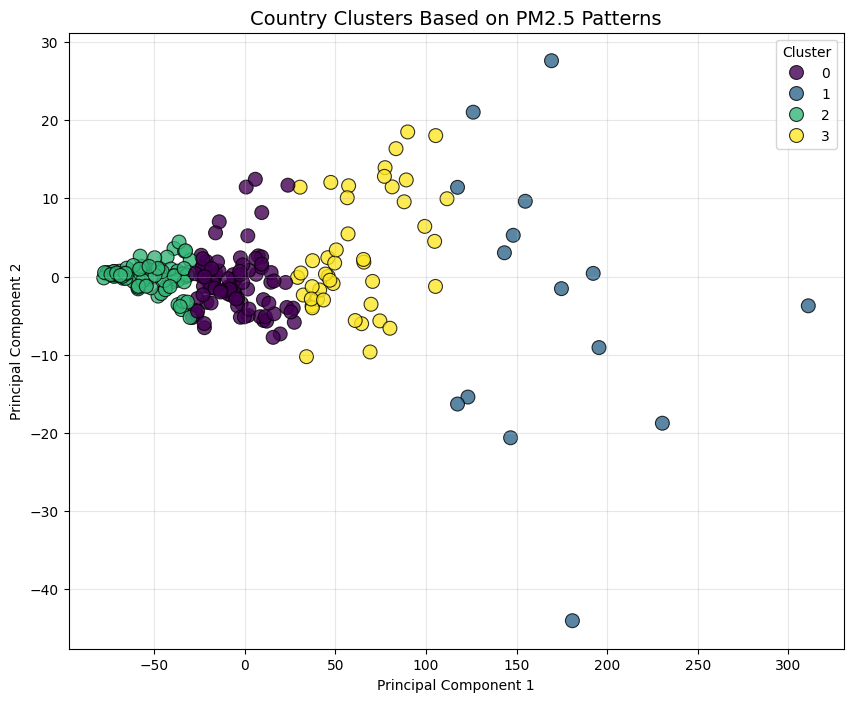

In [39]:
from sklearn.decomposition import PCA
import pandas as pd

df_pivot_for_pca = df_pivot.drop('Cluster', axis=1)
df_pivot_for_pca.columns = df_pivot_for_pca.columns.astype(str)

pca = PCA(n_components=2)
df_pca_components = pca.fit_transform(df_pivot_for_pca)

df_pca = pd.DataFrame(data=df_pca_components, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = df_pivot['Cluster'].values

plt.figure(figsize=(10,8))

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=df_pca,
    s=100,
    alpha=0.8,
    edgecolor='black'
)

plt.title("Country Clusters Based on PM2.5 Patterns", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(alpha=0.3)

plt.show()

This scatter plot helps to visualize the separation of the clusters in a reduced dimensional space. Each point represents a country, and its color indicates the cluster it belongs to. You can observe how distinct or overlapping the clusters are.

**Installing and Importing**

In [41]:
!pip install requests pandas matplotlib seaborn

**Loading Dataset**

In [72]:
import pandas as pd

df_city = pd.read_csv("GlobalWeatherRepository.csv")

df_city.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


**Selecting only useful columns**

In [73]:
df_city = df_city[[
    'country',
    'location_name',
    'temperature_celsius',
    'humidity',
    'air_quality_PM2.5'
]]

**Cleaning the dataset**

In [74]:
df_city = df_city.dropna()
df_city.rename(columns={
    'location_name': 'city',
    'air_quality_PM2.5': 'PM25'
}, inplace=True)

**Top polluted cities**

In [79]:
top_cities = df_city.groupby(['country', 'city'])['PM25'].mean().sort_values(ascending=False).head(10)

print(top_cities)

country       city            
Kuwait        Kuwait              176.700000
Chile         Santiago            151.240487
Indonesia     Jakarta             145.416100
Saudi Arabia  Riyadh              137.837522
China         Beijing             134.057173
India         New Delhi           111.527482
Vietnam       Ho Chi Minh City    104.600000
Kuwait        Kuwait City          92.289521
Vietnam       Hanoi                77.414652
Bangladesh    Dhaka                72.086543
Name: PM25, dtype: float64


**Average PM2.5 by country**

In [76]:
country_pm25 = df_city.groupby('country')['PM25'].mean().sort_values(ascending=False)
print(country_pm25.head(10))

country
Chile           151.240487
Saudi Arabia    137.837522
China           133.942286
India           111.527482
Kuwait           92.411855
Indonesia        84.831200
Bangladesh       72.086543
Südkorea         70.200000
Mauritania       66.694391
Bahrain          65.132945
Name: PM25, dtype: float64


**Correlation**

In [77]:
print(df_city[['PM25', 'temperature_celsius', 'humidity']].corr())

                         PM25  temperature_celsius  humidity
PM25                 1.000000             0.053923 -0.214029
temperature_celsius  0.053923             1.000000 -0.342447
humidity            -0.214029            -0.342447  1.000000


## **City-Level Analysis**

To complement country-level analysis, we used a city-level dataset.

### **Key Findings:**

- Cities like Kuwait, Santiago, and Jakarta show very high PM2.5 levels
- Significant variation exists within countries

### **Correlation Analysis:**

- PM2.5 vs Temperature → Very weak correlation (~0.05)
- PM2.5 vs Humidity → Slight negative correlation (~ -0.21)

### **Insight:**

Pollution is not strongly driven by short-term weather conditions.

PM2.5 shows very weak correlation with temperature and a slight negative correlation with humidity, suggesting that pollution levels are influenced more by human activities (e.g., industry, traffic) than by weather conditions alone.

While the SatPM2.5 dataset provides country-level long-term trends, we used a secondary dataset to analyze city-level variations and environmental factors affecting PM2.5 levels.

In [78]:
df_city.head()
df_city.describe()

,temperature_celsius,humidity,PM25
count,134488.00000,134488.000000,134488.000000
mean,21.29386,66.612203,24.232474
std,9.69997,23.899462,36.964158
min,-29.80000,2.000000,0.168000
25%,16.00000,51.000000,7.050000
50%,24.00000,72.000000,14.245000
75%,28.00000,86.000000,27.750000
max,49.20000,100.000000,1614.100000


**Top countries bar chart**

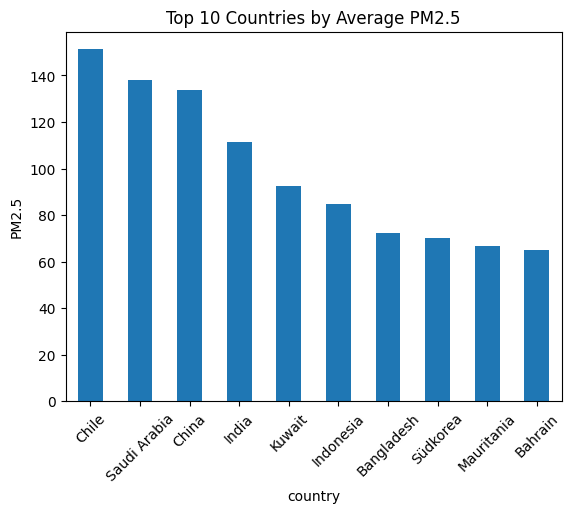

In [80]:
import matplotlib.pyplot as plt

country_pm25.head(10).plot(kind='bar')

plt.title("Top 10 Countries by Average PM2.5")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)
plt.show()

**Correlation heatmap**

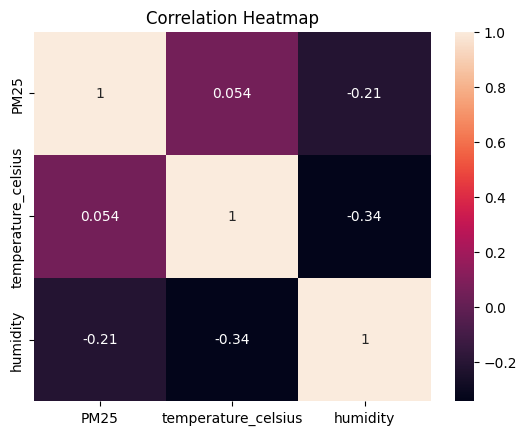

In [81]:
import seaborn as sns

sns.heatmap(df_city[['PM25', 'temperature_celsius', 'humidity']].corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Scatter plot**

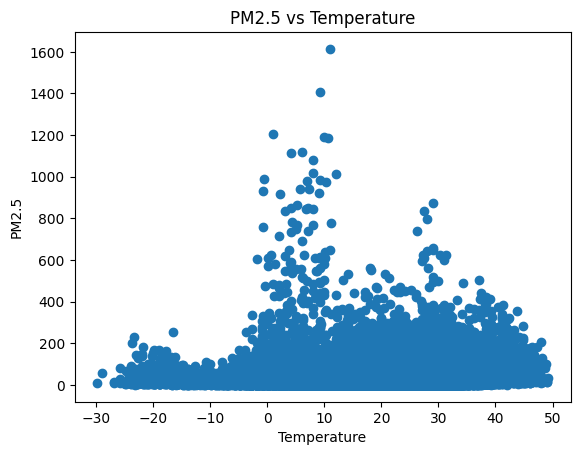

In [82]:
plt.scatter(df_city['temperature_celsius'], df_city['PM25'])

plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.title("PM2.5 vs Temperature")
plt.show()

# **Validation**

In [83]:
# ===============================
# VALIDATION: COUNTRY vs CITY DATA
# ===============================

print("VALIDATION ANALYSIS")

# 1. Model Insight (from SatPM2.5)
print("\n1. MODEL INSIGHT:")
print("PM2.5 is highly dependent on previous values (lag features)")
print("High R² (~0.96) indicates strong temporal patterns")

# 2. City Dataset Insight
print("\n2. CITY-LEVEL INSIGHT:")

corr = df_city[['PM25', 'temperature_celsius', 'humidity']].corr()
print(corr)

# Extract correlations
temp_corr = corr.loc['PM25', 'temperature_celsius']
hum_corr = corr.loc['PM25', 'humidity']

print(f"\nCorrelation with Temperature: {temp_corr:.3f}")
print(f"Correlation with Humidity: {hum_corr:.3f}")

# 3. Interpretation
print("\n3. VALIDATION INTERPRETATION:")

if abs(temp_corr) < 0.3 and abs(hum_corr) < 0.3:
    print("→ Weak correlation with weather variables")
    print("→ Confirms PM2.5 is not strongly influenced by short-term weather")
    print("→ Supports model assumption that pollution depends on historical trends")
else:
    print("→ Weather has noticeable impact on PM2.5")

print("\nFINAL CONCLUSION:")
print("City-level data VALIDATES the model’s assumption that PM2.5 patterns are stable and time-dependent.")

VALIDATION ANALYSIS

1. MODEL INSIGHT:
PM2.5 is highly dependent on previous values (lag features)
High R² (~0.96) indicates strong temporal patterns

2. CITY-LEVEL INSIGHT:
                         PM25  temperature_celsius  humidity
PM25                 1.000000             0.053923 -0.214029
temperature_celsius  0.053923             1.000000 -0.342447
humidity            -0.214029            -0.342447  1.000000

Correlation with Temperature: 0.054
Correlation with Humidity: -0.214

3. VALIDATION INTERPRETATION:
→ Weak correlation with weather variables
→ Confirms PM2.5 is not strongly influenced by short-term weather
→ Supports model assumption that pollution depends on historical trends

FINAL CONCLUSION:
City-level data VALIDATES the model’s assumption that PM2.5 patterns are stable and time-dependent.


## **Validation Using City-Level Data**

To validate our model, we compared:

### **Model Insight:**
- PM2.5 depends on past values (lag features)
- Strong temporal patterns (R² ≈ 0.96)

### **City-Level Insight:**
- Weak correlation with temperature and humidity
- Pollution not driven by short-term environmental factors

### **Final Conclusion:**

City-level data supports our model assumption that:

→ PM2.5 is primarily driven by long-term factors  
→ Pollution patterns are stable and predictable over time  

This validates the effectiveness of our predictive approach.

## **Final Conclusion**

This project successfully:

- Identified global pollution patterns
- Built accurate predictive models
- Discovered country clusters
- Validated findings using real-world city data

### **Key Takeaways:**

- PM2.5 is highly predictable using historical data
- Temporal trends dominate over environmental factors
- Linear Regression is effective for pollution prediction

---

This project demonstrates how data mining techniques can be applied to understand and predict real-world environmental challenges.

---